# Performance Analytics

## Objective

The objective of this notebook is to evaluate the performance of mutual fund schemes using industry-standard financial metrics.

Metrics Evaluated:

- CAGR (Compound Annual Growth Rate)
- Volatility
- Sharpe Ratio
- Beta
- Alpha
- Value at Risk (VaR)

These metrics help assess:

- Long-term growth potential
- Investment risk
- Risk-adjusted performance
- Manager skill
- Downside risk

The analysis provides actionable insights for investors, financial advisors, and portfolio managers.

# Import Required Libraries

This section imports all required Python libraries for data manipulation, visualization, database connectivity, and financial analytics.

In [1]:
from pathlib import Path

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sqlalchemy import create_engine

plt.style.use("default")

# Data Loading

## Objective

Load the performance metrics dataset generated from NAV history and enrich it with mutual fund scheme information stored in the data warehouse.

This allows analysis to be performed using both scheme names and AMFI codes.

In [2]:
BASE_DIR = Path.cwd().parent

DB_PATH = (
    BASE_DIR
    / "data"
    / "db"
    / "bluestock_mf.db"
)

engine = create_engine(
    f"sqlite:///{DB_PATH}"
)

metrics = pd.read_csv(
    BASE_DIR
    / "data"
    / "processed"
    / "performance_metrics.csv"
)

funds = pd.read_sql(
    """
    SELECT
        amfi_code,
        scheme_name
    FROM dim_fund
    """,
    engine
)

metrics = metrics.merge(
    funds,
    on="amfi_code",
    how="left"
)

metrics["fund_label"] = (
    metrics["scheme_name"]
    +
    " ("
    +
    metrics["amfi_code"].astype(str)
    +
    ")"
)

metrics.head()

,amfi_code,cagr,volatility,sharpe_ratio,beta,alpha,var_95,scheme_name,fund_label
0,119551,0.247726,0.137414,1.244653,0.227065,0.157425,-0.012846,SBI Bluechip Fund - Regular Plan - Growth,SBI Bluechip Fund - Regular Plan - Growth (119...
1,119552,0.206770,0.139394,0.989149,0.562062,0.104197,-0.013501,SBI Bluechip Fund - Direct Plan - Growth,SBI Bluechip Fund - Direct Plan - Growth (119552)
2,119598,0.310957,0.251406,0.965196,2.128957,0.115068,-0.024507,SBI Small Cap Fund - Regular Plan - Growth,SBI Small Cap Fund - Regular Plan - Growth (11...
3,119599,0.019800,0.249501,-0.037147,1.303311,-0.087375,-0.026859,SBI Small Cap Fund - Direct Plan - Growth,SBI Small Cap Fund - Direct Plan - Growth (119...
4,119120,0.056722,0.039671,-0.100538,0.022875,-0.005359,-0.003938,SBI Magnum Gilt Fund - Regular Plan - Growth,SBI Magnum Gilt Fund - Regular Plan - Growth (...


# Dataset Overview

## Objective

Understand the structure, size, and characteristics of the performance metrics dataset before conducting detailed analysis.

In [3]:
metrics.info()

<class 'pandas.DataFrame'>
RangeIndex: 40 entries, 0 to 39
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   amfi_code     40 non-null     int64  
 1   cagr          40 non-null     float64
 2   volatility    40 non-null     float64
 3   sharpe_ratio  40 non-null     float64
 4   beta          40 non-null     float64
 5   alpha         40 non-null     float64
 6   var_95        40 non-null     float64
 7   scheme_name   40 non-null     str    
 8   fund_label    40 non-null     str    
dtypes: float64(6), int64(1), str(2)
memory usage: 2.9 KB


In [4]:
metrics.describe().T

,count,mean,std,min,25%,50%,75%,max
amfi_code,40.0,120247.000000,14534.998667,100016.000000,118632.750000,119551.500000,120842.250000,149324.000000
cagr,40.0,0.160740,0.098831,0.011295,0.066076,0.159661,0.235135,0.314811
volatility,40.0,0.149444,0.066753,0.004939,0.138487,0.145582,0.181890,0.257973
sharpe_ratio,40.0,0.647002,0.532053,-0.439062,0.170134,0.756622,1.061384,1.508048
beta,40.0,0.944787,0.831462,-0.001121,0.349806,0.801984,1.362863,3.782607
alpha,40.0,0.042404,0.088626,-0.184963,-0.011047,0.019556,0.116820,0.188893
var_95,40.0,-0.014711,0.006821,-0.026859,-0.018394,-0.014376,-0.013247,-0.000222


## Interpretation

The dataset contains performance metrics calculated for all mutual fund schemes.

The metrics collectively describe growth, risk, market sensitivity, risk-adjusted return, and downside risk characteristics.

# CAGR Analysis

## What is CAGR?

Compound Annual Growth Rate (CAGR) measures the annualized growth rate of an investment after accounting for compounding effects.

## Why It Matters

Investors use CAGR to compare long-term investment performance.

Higher CAGR values generally indicate superior wealth creation potential.

## Business Question

Which mutual fund schemes have delivered the strongest long-term growth?

In [5]:
top_cagr = (
    metrics
    .sort_values(
        "cagr",
        ascending=False
    )
    .head(10)
)

top_cagr[
    [
        "fund_label",
        "cagr"
    ]
]

,fund_label,cagr
12,ICICI Pru Midcap Fund - Regular - Growth (120505),0.314811
2,SBI Small Cap Fund - Regular Plan - Growth (11...,0.310957
39,DSP Small Cap Fund - Regular - Growth (149324),0.309658
36,Mirae Asset Tax Saver Fund - Regular - Growth ...,0.306432
34,Mirae Asset Large Cap Fund - Regular - Growth ...,0.297120
22,Kotak Flexicap Fund - Regular - Growth (120843),0.296483
7,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,0.288994
38,DSP Midcap Fund - Regular - Growth (149323),0.283816
26,Axis Midcap Fund - Regular - Growth (119094),0.270760
0,SBI Bluechip Fund - Regular Plan - Growth (119...,0.247726


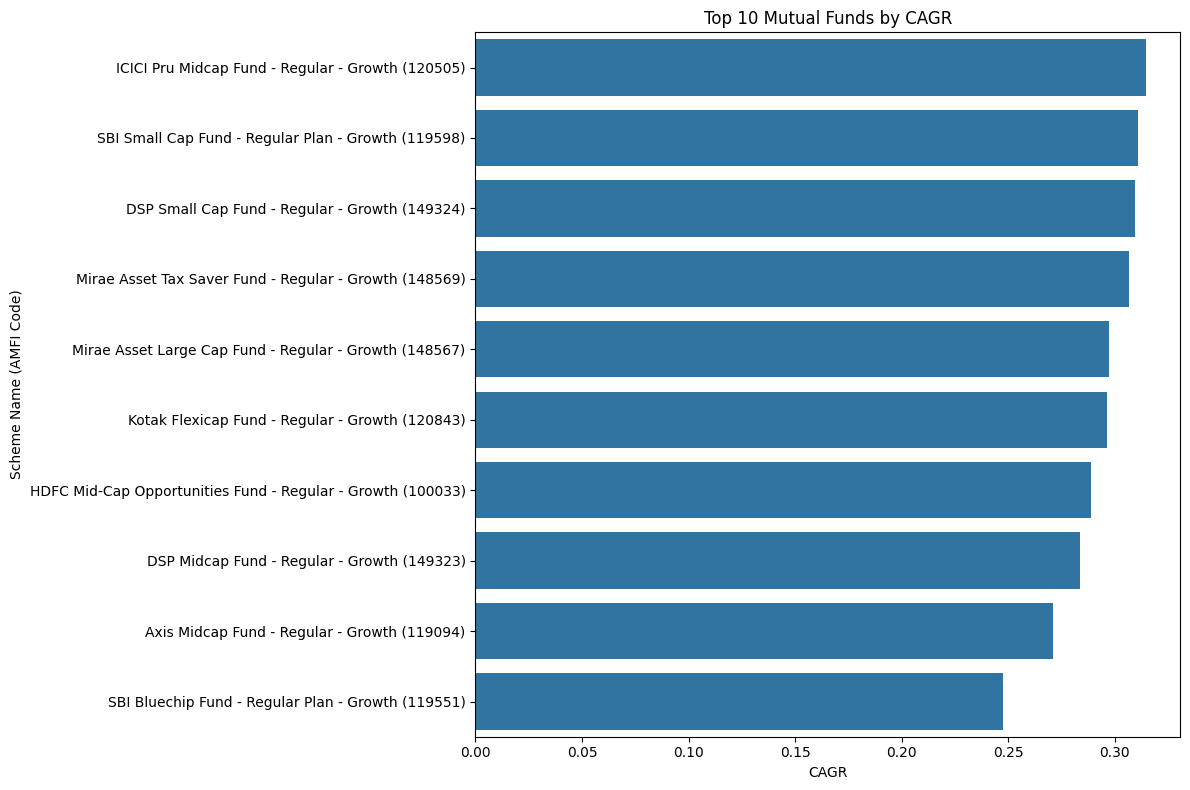

In [6]:
plt.figure(figsize=(12,8))

sns.barplot(
    data=top_cagr,
    x="cagr",
    y="fund_label"
)

plt.title(
    "Top 10 Mutual Funds by CAGR"
)

plt.xlabel(
    "CAGR"
)

plt.ylabel(
    "Scheme Name (AMFI Code)"
)

plt.tight_layout()

plt.show()

## Interpretation

The chart ranks mutual fund schemes based on annualized growth performance.

Funds appearing at the top of the chart have demonstrated superior long-term wealth creation capability.

# Volatility Analysis

## What is Volatility?

Volatility measures the variability of returns over time.

Higher volatility indicates greater uncertainty and investment risk.

## Business Question

Which funds exhibit the highest and lowest risk profiles?

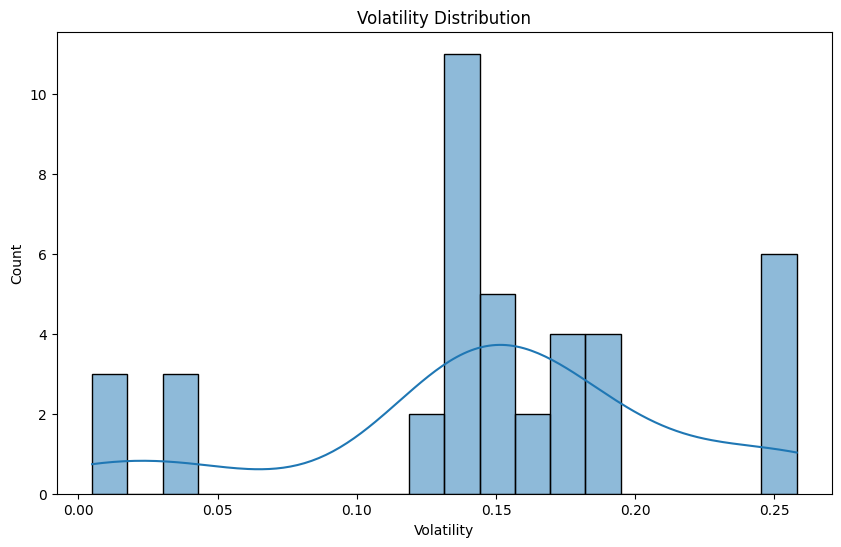

In [7]:
plt.figure(figsize=(10,6))

sns.histplot(
    metrics["volatility"],
    bins=20,
    kde=True
)

plt.title(
    "Volatility Distribution"
)

plt.xlabel(
    "Volatility"
)

plt.show()

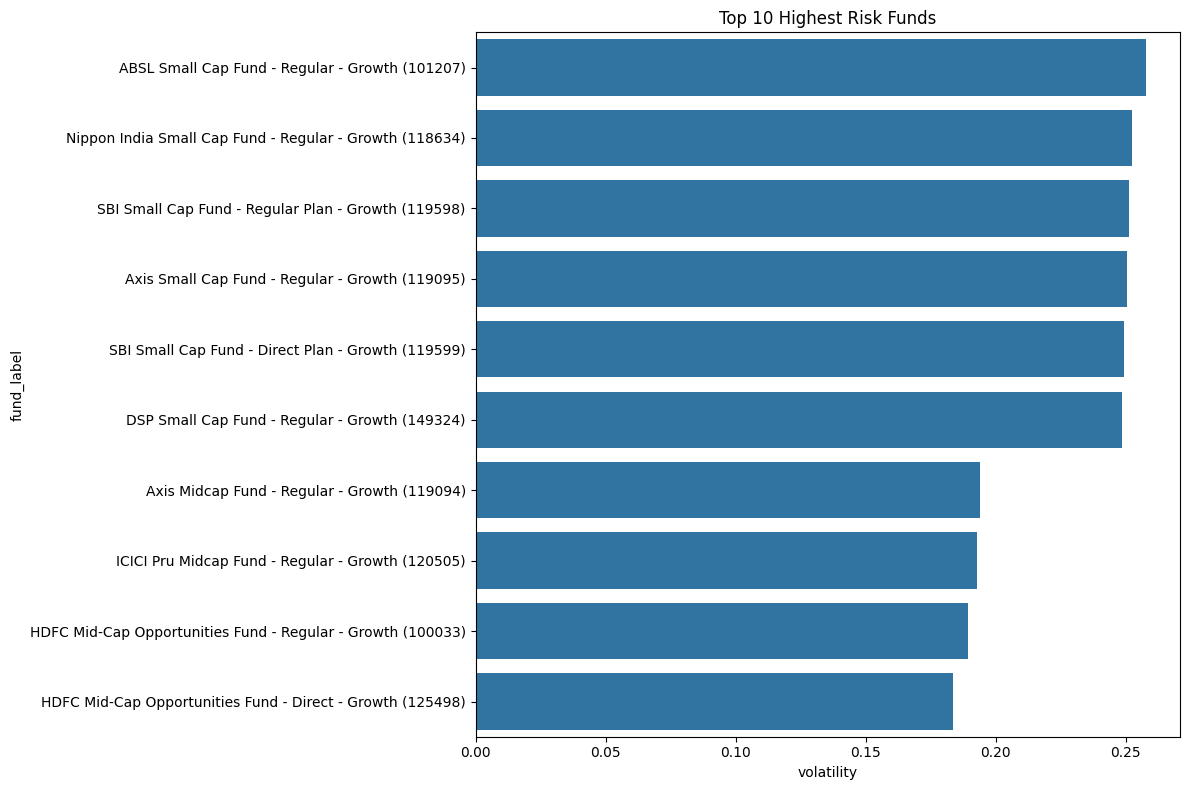

In [8]:
high_risk = (
    metrics
    .sort_values(
        "volatility",
        ascending=False
    )
    .head(10)
)

plt.figure(figsize=(12,8))

sns.barplot(
    data=high_risk,
    x="volatility",
    y="fund_label"
)

plt.title(
    "Top 10 Highest Risk Funds"
)

plt.tight_layout()

plt.show()

## Interpretation

Funds with higher volatility experience larger fluctuations in returns.

These funds may generate higher returns but expose investors to greater uncertainty.

## Business Insight

High-volatility funds may be suitable for aggressive investors, while low-volatility funds are more appropriate for conservative investors.

# Sharpe Ratio Analysis

## What is Sharpe Ratio?

Sharpe Ratio measures the excess return generated per unit of risk.

It is one of the most important risk-adjusted performance metrics in finance.

## Business Question

Which funds generate the best returns relative to the risk taken?

In [9]:
top_sharpe = (
    metrics
    .sort_values(
        "sharpe_ratio",
        ascending=False
    )
    .head(10)
)

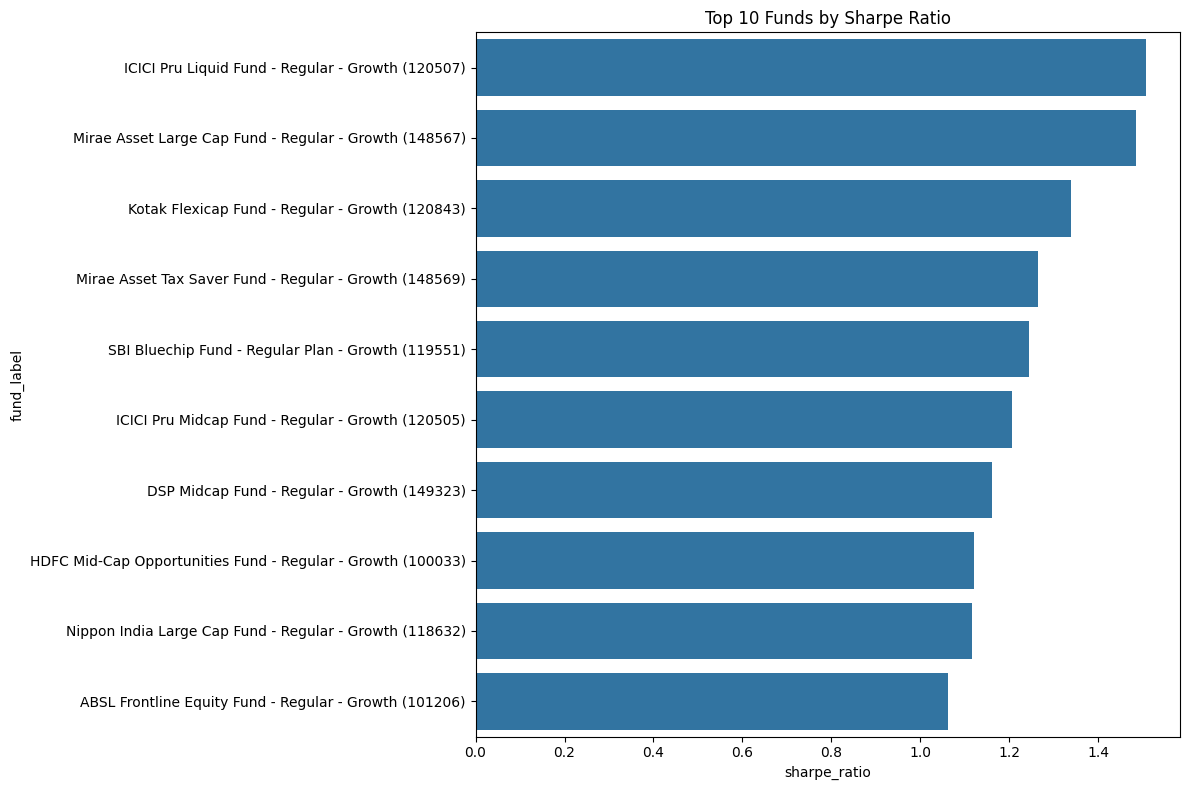

In [10]:
plt.figure(figsize=(12,8))

sns.barplot(
    data=top_sharpe,
    x="sharpe_ratio",
    y="fund_label"
)

plt.title(
    "Top 10 Funds by Sharpe Ratio"
)

plt.tight_layout()

plt.show()

## Interpretation

Higher Sharpe Ratios indicate superior risk-adjusted performance.

These funds have generated more return for every unit of risk assumed.

## Business Insight

Funds with consistently high Sharpe Ratios should be prioritized in recommendation engines and advisory portfolios.

# Alpha Analysis

## What is Alpha?

Alpha measures the excess return generated by a fund beyond what would be expected based on its market risk.

Positive Alpha indicates outperformance, while negative Alpha indicates underperformance.

## Why It Matters

Alpha is often viewed as a measure of fund manager skill.

## Business Question

Which mutual funds consistently outperform market expectations?

In [11]:
top_alpha = (
    metrics
    .sort_values(
        "alpha",
        ascending=False
    )
    .head(10)
)

top_alpha[
    [
        "fund_label",
        "alpha"
    ]
]

,fund_label,alpha
34,Mirae Asset Large Cap Fund - Regular - Growth ...,0.188893
36,Mirae Asset Tax Saver Fund - Regular - Growth ...,0.181741
22,Kotak Flexicap Fund - Regular - Growth (120843),0.160136
7,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,0.159155
38,DSP Midcap Fund - Regular - Growth (149323),0.157610
0,SBI Bluechip Fund - Regular Plan - Growth (119...,0.157425
26,Axis Midcap Fund - Regular - Growth (119094),0.148561
11,ICICI Pru Bluechip Fund - Direct - Growth (120...,0.133612
15,Nippon India Large Cap Fund - Regular - Growth...,0.133133
39,DSP Small Cap Fund - Regular - Growth (149324),0.122076


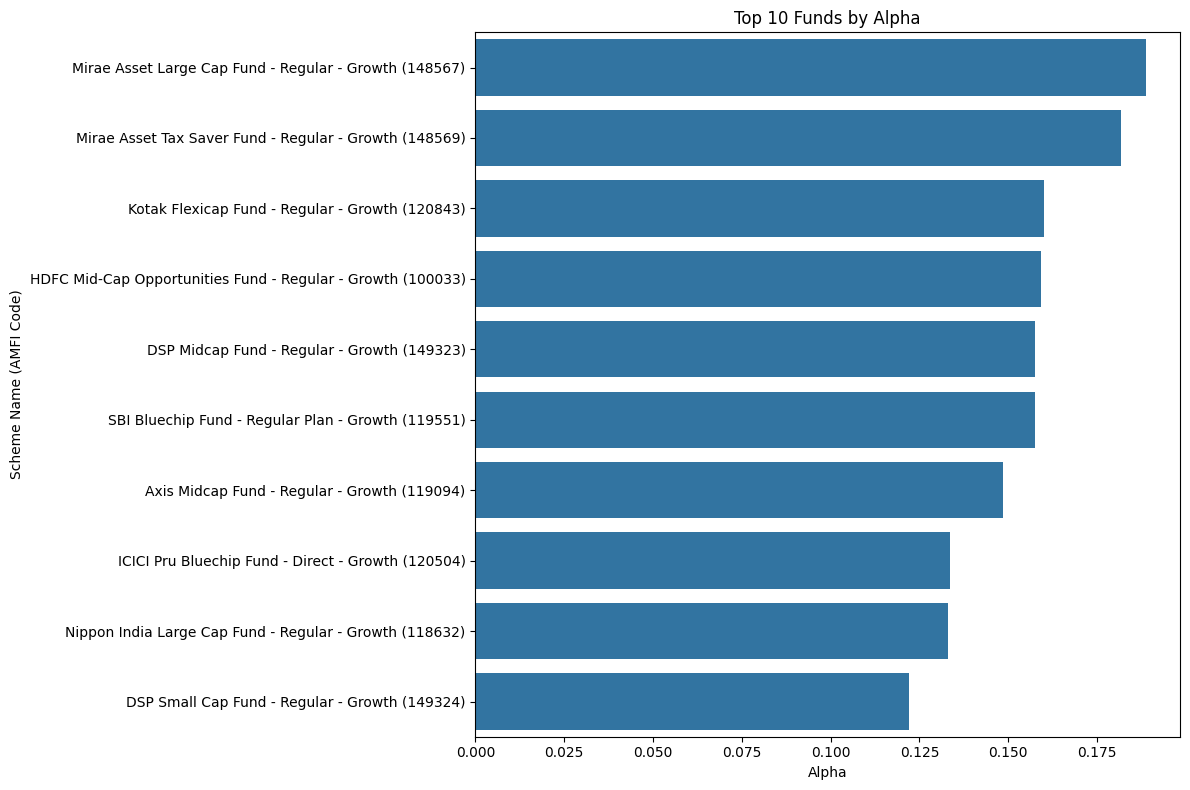

In [12]:
plt.figure(figsize=(12,8))

sns.barplot(
    data=top_alpha,
    x="alpha",
    y="fund_label"
)

plt.title(
    "Top 10 Funds by Alpha"
)

plt.xlabel(
    "Alpha"
)

plt.ylabel(
    "Scheme Name (AMFI Code)"
)

plt.tight_layout()

plt.show()

## Interpretation

Funds with positive Alpha have generated returns above expectations.

This suggests effective portfolio management and investment decision-making.

## Business Insight

Funds with consistently positive Alpha can be positioned as premium actively managed investment products.

# Beta Analysis

## What is Beta?

Beta measures a fund's sensitivity to overall market movements.

### Interpretation

Beta > 1 : Aggressive Fund

Beta < 1 : Defensive Fund

Beta = 1 : Moves in line with the market

## Business Question

Which funds exhibit the highest market sensitivity?

In [13]:
top_beta = (
    metrics
    .sort_values(
        "beta",
        ascending=False
    )
    .head(10)
)

top_beta[
    [
        "fund_label",
        "beta"
    ]
]

,fund_label,beta
6,HDFC Top 100 Fund - Direct Plan - Growth (125497),3.782607
5,HDFC Top 100 Fund - Regular Plan - Growth (100...,2.680576
2,SBI Small Cap Fund - Regular Plan - Growth (11...,2.128957
12,ICICI Pru Midcap Fund - Regular - Growth (120505),2.127730
37,DSP Top 100 Equity Fund - Regular - Growth (14...,2.018873
39,DSP Small Cap Fund - Regular - Growth (149324),1.983250
28,ABSL Frontline Equity Fund - Regular - Growth ...,1.796288
17,Nippon India Small Cap Fund - Regular - Growth...,1.669987
13,ICICI Pru Value Discovery Fund - Regular - Gro...,1.560793
20,Kotak Bluechip Fund - Regular - Growth (120841),1.365501


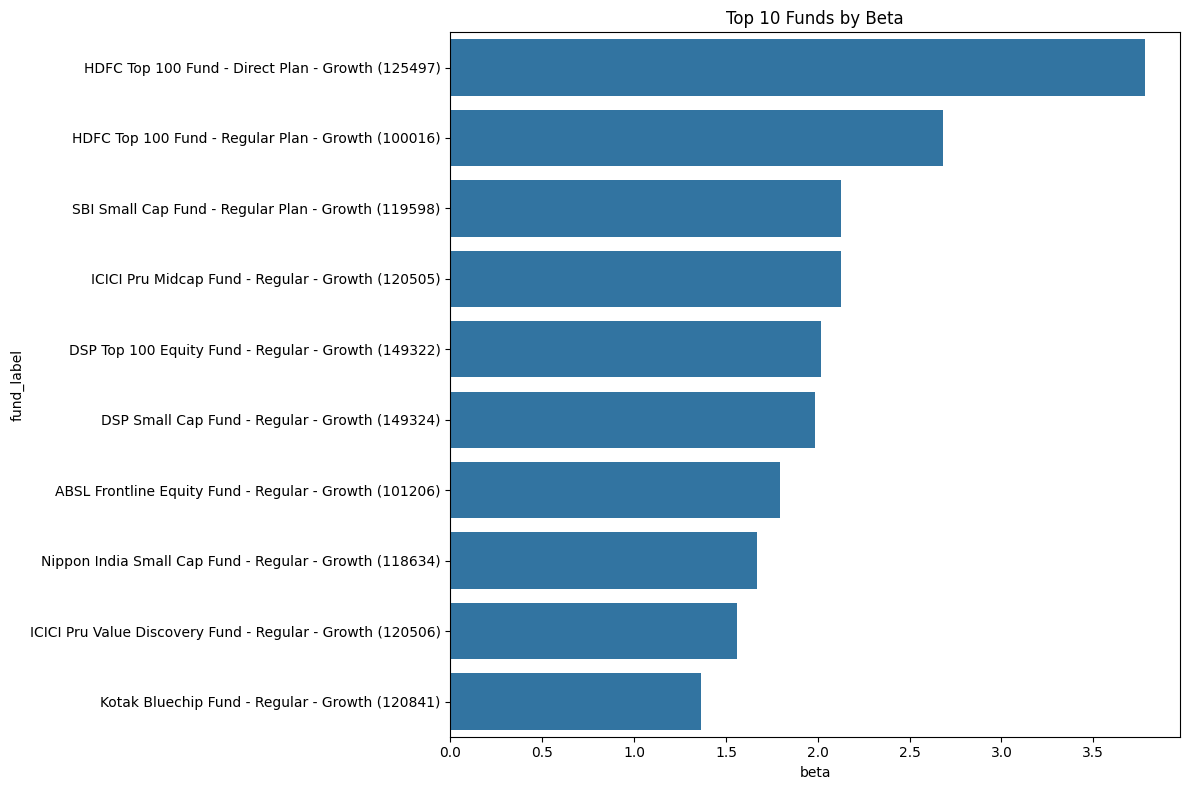

In [14]:
plt.figure(figsize=(12,8))

sns.barplot(
    data=top_beta,
    x="beta",
    y="fund_label"
)

plt.title(
    "Top 10 Funds by Beta"
)

plt.tight_layout()

plt.show()

## Interpretation

Funds with higher Beta values tend to react more strongly to market movements.

These funds may generate higher returns during bull markets but may also experience larger declines during market corrections.

## Business Insight

Higher Beta funds are generally suitable for aggressive investors with higher risk tolerance.

# Value at Risk (VaR) Analysis

## What is VaR?

Value at Risk estimates the maximum expected loss over a specified period at a given confidence level.

In this project, a 95% confidence level is used.

## Business Question

Which funds expose investors to the highest downside risk?

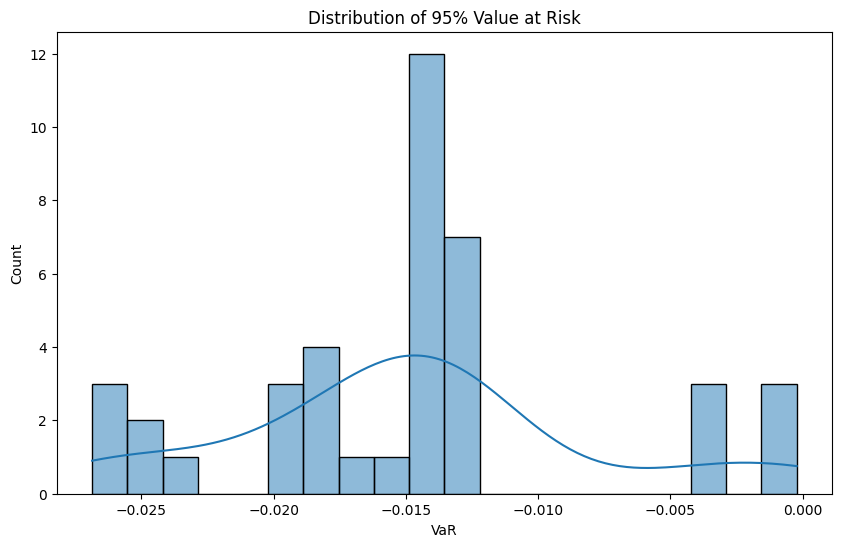

In [15]:
plt.figure(figsize=(10,6))

sns.histplot(
    metrics["var_95"],
    bins=20,
    kde=True
)

plt.title(
    "Distribution of 95% Value at Risk"
)

plt.xlabel(
    "VaR"
)

plt.show()

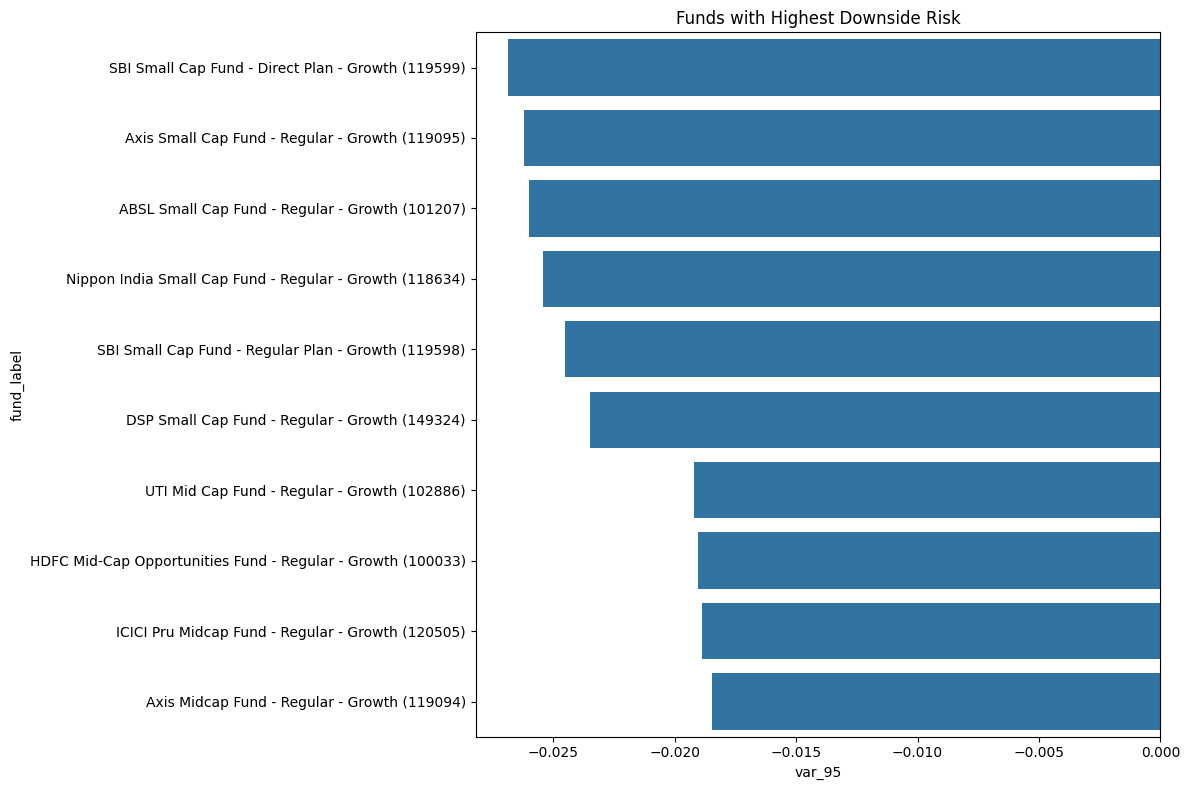

In [16]:
high_var = (
    metrics
    .sort_values(
        "var_95"
    )
    .head(10)
)

plt.figure(figsize=(12,8))

sns.barplot(
    data=high_var,
    x="var_95",
    y="fund_label"
)

plt.title(
    "Funds with Highest Downside Risk"
)

plt.tight_layout()

plt.show()

## Interpretation

Funds with more negative VaR values are exposed to larger potential losses during adverse market conditions.

## Business Insight

Investors with lower risk tolerance should prioritize funds with smaller downside risk exposure.

# Risk vs Return Analysis

## Objective

Evaluate the relationship between risk and reward across all mutual fund schemes.

Ideal funds provide:

- High CAGR
- Low Volatility

This analysis helps identify efficient investment opportunities.

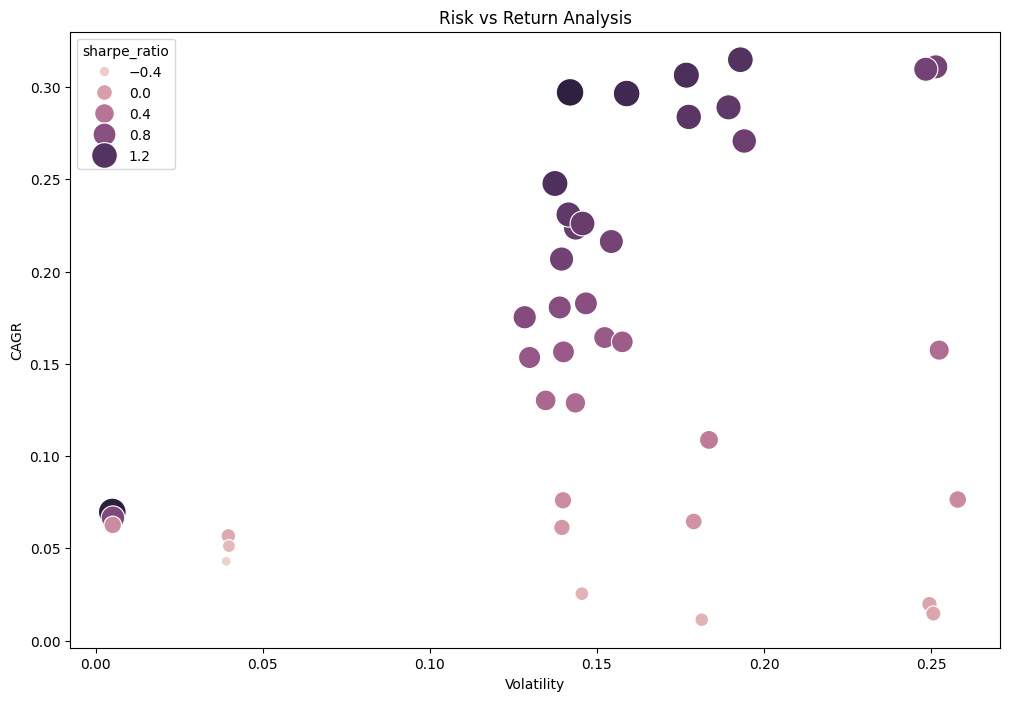

In [17]:
plt.figure(figsize=(12,8))

sns.scatterplot(
    data=metrics,
    x="volatility",
    y="cagr",
    size="sharpe_ratio",
    hue="sharpe_ratio",
    sizes=(50,400)
)

plt.title(
    "Risk vs Return Analysis"
)

plt.xlabel(
    "Volatility"
)

plt.ylabel(
    "CAGR"
)

plt.show()

# Correlation Analysis

## Objective

Understand relationships among growth, risk, risk-adjusted performance, and downside risk metrics.

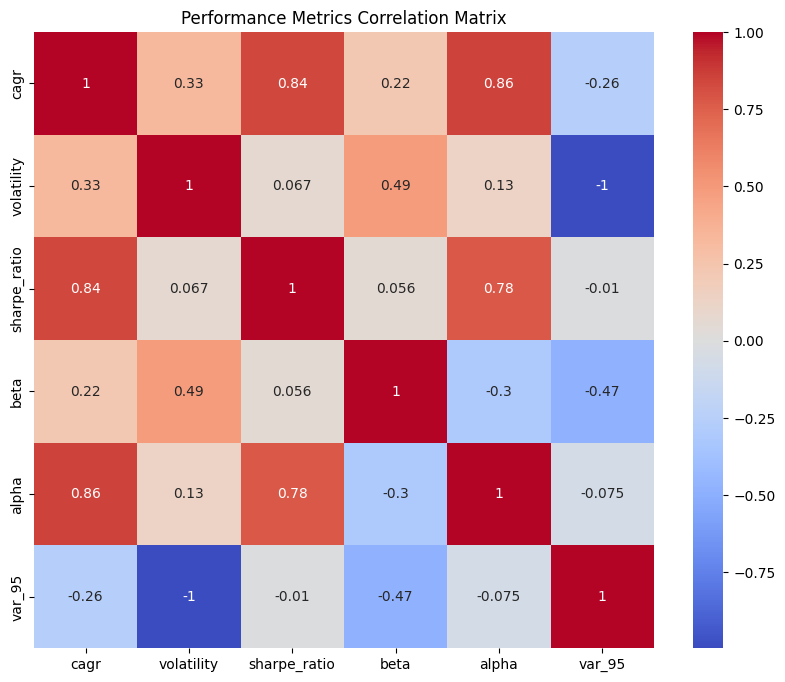

In [18]:
corr = metrics[
    [
        "cagr",
        "volatility",
        "sharpe_ratio",
        "beta",
        "alpha",
        "var_95"
    ]
].corr()

plt.figure(figsize=(10,8))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm"
)

plt.title(
    "Performance Metrics Correlation Matrix"
)

plt.show()

## Interpretation

The heatmap reveals relationships among key performance indicators.

Positive correlations indicate metrics moving together, while negative correlations suggest inverse relationships.

## Business Insight

Understanding metric relationships improves portfolio diversification and risk management strategies.

# Top Recommended Funds

## Objective

Identify funds that demonstrate strong growth, attractive risk-adjusted returns, and acceptable risk levels.

In [19]:
recommended = (
    metrics
    .sort_values(
        [
            "sharpe_ratio",
            "cagr"
        ],
        ascending=False
    )
    .head(10)
)

recommended[
    [
        "fund_label",
        "cagr",
        "sharpe_ratio",
        "volatility",
        "alpha",
        "var_95"
    ]
]

,fund_label,cagr,sharpe_ratio,volatility,alpha,var_95
14,ICICI Pru Liquid Fund - Regular - Growth (120507),0.069690,1.508048,0.004939,0.007272,-0.000222
34,Mirae Asset Large Cap Fund - Regular - Growth ...,0.297120,1.483518,0.141937,0.188893,-0.013560
22,Kotak Flexicap Fund - Regular - Growth (120843),0.296483,1.338216,0.158870,0.160136,-0.014508
36,Mirae Asset Tax Saver Fund - Regular - Growth ...,0.306432,1.263220,0.176740,0.181741,-0.017118
0,SBI Bluechip Fund - Regular Plan - Growth (119...,0.247726,1.244653,0.137414,0.157425,-0.012846
12,ICICI Pru Midcap Fund - Regular - Growth (120505),0.314811,1.206020,0.192909,0.105138,-0.018892
38,DSP Midcap Fund - Regular - Growth (149323),0.283816,1.160297,0.177462,0.157610,-0.017882
7,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,0.288994,1.120102,0.189367,0.159155,-0.019034
15,Nippon India Large Cap Fund - Regular - Growth...,0.230938,1.116999,0.141484,0.133133,-0.013954
28,ABSL Frontline Equity Fund - Regular - Growth ...,0.226048,1.061535,0.145682,0.046996,-0.013282


## Interpretation

These funds consistently rank highly across multiple performance dimensions and represent strong candidates for investment consideration.

# Executive Recommendations

Based on the analysis:

1. Prioritize funds exhibiting strong CAGR and Sharpe Ratios.
2. Monitor high-volatility funds carefully despite attractive returns.
3. Consider positive Alpha funds as evidence of active management skill.
4. Incorporate VaR into risk management decisions.
5. Use risk-return analysis when constructing diversified portfolios.

# Conclusion

This notebook evaluated mutual fund performance using industry-standard financial metrics.

Key findings include:

- Identification of top-performing funds based on CAGR.
- Assessment of risk through Volatility and VaR.
- Evaluation of risk-adjusted performance using Sharpe Ratio.
- Analysis of manager skill through Alpha.
- Examination of market sensitivity using Beta.

Together, these metrics provide a comprehensive framework for mutual fund evaluation and investment decision-making.

The insights generated in this analysis can support portfolio construction, fund recommendations, advisor decision-making, and dashboard development.